# Chapter 2: The TensorFlow Way

In [1]:
import tensorflow as tf
import numpy as np

Using eager execution allows TensorFlow to immediately evaluation operation values without having to refer to different nodes of a computational graph to be later compiled and executed. Below we are able to iterate through the multiplicative results of the operation and print the resulting values

In [4]:
# Simple operations on Numpy arrays using TF
x_vals = np.array([1., 3., 5., 7., 9.])
x_data = tf.Variable(x_vals, dtype=tf.float32)
m_const = tf.constant(3.)
operation = tf.multiply(x_data, m_const)
for result in operation:
    print(result)

tf.Tensor(3.0, shape=(), dtype=float32)
tf.Tensor(9.0, shape=(), dtype=float32)
tf.Tensor(15.0, shape=(), dtype=float32)
tf.Tensor(21.0, shape=(), dtype=float32)
tf.Tensor(27.0, shape=(), dtype=float32)


## Layering nested operations

Chaining operations together

In [4]:
# Create data
my_array = np.array([[1., 3., 5., 7., 9.],
					[-2., 0., 2., 4., 6.],
					[-6., -3., 0., 3., 6.]])
x_vals = np.array([my_array, my_array + 1])
x_data = tf.Variable(x_vals, dtype=tf.float32)

# Create constants
m1 = tf.constant([[1.], [0.], [-1.], [2.], [4.]])
m2 = tf.constant([[2.]])
a1 = tf.constant([[10.]])

# Create operations
def prod1(a, b):
    return tf.matmul(a, b)
def prod2(a, b):
    return tf.matmul(a, b)
def add1(a, b):
    return tf.add(a, b)

# Nest functions and execute
result = add1(prod2(prod1(x_data, m1), m2), a1)
print(result.numpy())

[[[102.]
  [ 66.]
  [ 58.]]

 [[114.]
  [ 78.]
  [ 70.]]]


Using functions and classes to write code makes it easier to read and debugging more effective

_Eager execution prevent the "kitchen sink" programming style_

Prevent you from putting everything in the global scope of the program. Kitchen sink refers to covering everything under one umbrella, but eager execution helps to separate the steps into components that can be executed individually. Allows adoption of functional or object-oriented programming

In [6]:
# Object-oriented method (classes)
class Operation:
    def __init__(self, a):
        self.result = a
    def apply(self, func, b):
        self.result = func(self.result, b)
        return self

operation = (Operation(a=x_data))\
    .apply(prod1, b=m1)\
    .apply(prod2, b=m2)\
    .apply(add1, b=a1)
print(operation.result.numpy())

[[[102.]
  [ 66.]
  [ 58.]]

 [[114.]
  [ 78.]
  [ 70.]]]


## Handling variable matrices

there can be instances where the dimensions are unknown or change during data processing. Dimensions that change or vary are designated value `None`

In [6]:
# Assigning variable with arbitrary number of rows
v = tf.Variable(initial_value=tf.random.normal(shape=(1, 5)),
                shape=tf.TensorShape((None, 5))) # default initializes 1 row
print("Before changing")
print(v)

v.assign(tf.random.normal(shape=(10, 5))) # changes to 10 rows
print("After changing")
print(v)

Before changing
<tf.Variable 'Variable:0' shape=(None, 5) dtype=float32, numpy=
array([[ 0.73022306, -0.68670994, -1.3504177 , -0.6823519 , -0.7690181 ]],
      dtype=float32)>
After changing
<tf.Variable 'Variable:0' shape=(None, 5) dtype=float32, numpy=
array([[ 0.17207876,  0.9548642 , -2.4201381 , -0.29396814,  0.7970605 ],
       [-0.12608585, -0.9261787 , -0.9616564 , -1.2003714 , -0.65673167],
       [-0.15156327,  0.9533613 ,  0.9923246 , -2.757566  ,  0.44487333],
       [-0.1197399 , -0.8672994 ,  1.6147463 ,  0.0686544 ,  0.3882783 ],
       [ 1.032542  , -1.4356863 ,  1.1074864 ,  0.45089325, -1.6404599 ],
       [-0.5712446 ,  0.25815418,  0.6590706 ,  0.52069306,  1.4343278 ],
       [ 1.1738964 , -0.85800284,  1.3065784 ,  0.5568403 , -0.16532104],
       [ 0.82310826,  0.4069675 ,  0.20818782,  0.3157649 , -0.90345   ],
       [ 0.2885773 ,  1.5408815 ,  0.60691476, -1.3244678 ,  0.755759  ],
       [ 0.5262349 , -1.7181352 , -0.02335227,  0.02232852, -0.9101742 ]],
   

Fine for matrix multiplication to have variable rows because it won't affect the arrangement of the operations. Plus most of the time you'll be working with different batch sizes (different number of rows). But it is still recommended to be __explicit about data dimensions as much as possible__

## Working with multiple layers

Connecting various layers that have data propogating through them. Layers here refer to different computational methods that are applied to the current tensor.

Computational graphs can get large, so introduce ways to name operations and create scopes for layers.

In [3]:
# Set the parameters of "image set"
batch_size = [1]
x_shape = [4, 4, 1]
x_data = tf.random.uniform(shape=batch_size + x_shape)
print("-- ORIGINAL IMAGE --")
print(x_data)

# conv2d (moving average window)
def mov_avg_layer(x):
    my_filter = tf.constant(0.25, shape=[2, 2, 1, 1])
    my_strides = [1, 2, 2, 1]
    layer = tf.nn.conv2d(x, my_filter, my_strides, padding="SAME", name="Moving_Avg_Window")
    return layer
# Output = (W-F-2P)/S + 1

# Custom layer to matmul, +1 and sigmoid
def custom_layer(input_matrix):
    input_matrix_squeezed = tf.squeeze(input_matrix)
    A = tf.constant([[1., 2.], [-1, 3.]])
    b = tf.constant(1., shape=[2,2])
    temp1 = tf.matmul(A, input_matrix_squeezed)
    temp = tf.add(temp1, b)
    return tf.sigmoid(temp)

# Call the layers together
first_layer = mov_avg_layer(x_data)
second_layer = custom_layer(first_layer)
print("-- PROCESSED IMAGE --")
print(second_layer)

-- ORIGINAL IMAGE --
tf.Tensor(
[[[[0.7765738 ]
   [0.59103465]
   [0.2574947 ]
   [0.9714035 ]]

  [[0.06001127]
   [0.97225404]
   [0.37915945]
   [0.6281358 ]]

  [[0.03243566]
   [0.7139051 ]
   [0.83239686]
   [0.348225  ]]

  [[0.43715918]
   [0.32873607]
   [0.6930994 ]
   [0.09405804]]]], shape=(1, 4, 4, 1), dtype=float32)
-- PROCESSED IMAGE --
tf.Tensor(
[[0.91341686 0.9270977 ]
 [0.8226212  0.8717797 ]], shape=(2, 2), dtype=float32)


## Implementing loss functions

Loss functions are a key aspect of machine learning models. They measure the distance between the predicted values and the target (true) values, to help the model close the gap.

Loss functions tell how good or bad the current output is, by comparing the target to predictions and provides a numerical quantification of the difference between the 2 for all data used

In [27]:
import matplotlib.pyplot as plt
import tensorflow as tf

### Loss Functions for Regression Problems

In [25]:
# Create target and data
x_vals = tf.linspace(-1., 1., 500)
target = tf.constant(0.)

# L2 loss function
def l2(y_true, y_pred):
    return tf.square(y_true - y_pred) 

# L1 loss function
def l1(y_true, y_pred):
    return tf.abs(y_true - y_pred)

# Pseudo-Huber loss 
def phuber1(y_true, y_pred):
    delta1 = tf.constant(0.25)
    return tf.multiply(tf.square(delta1), tf.sqrt(1. + tf.square((y_true - y_pred)/delta1)) - 1.)

def phuber2(y_true, y_pred):
    delta2 = tf.constant(5.)
    return tf.multiply(tf.square(delta2), tf.sqrt(1. + tf.square((y_true - y_pred)/delta2)) - 1.)

__Notes about the loss functions above__

* `L2 Norm` - curved near the target, so algorithms will slow down as the values converge closer to the target (difference approaches closer to 0)
* `L1 Norm` - better for outliers because not as steep for larger values, but not as smooth at the target, resulting in poor convergence nearer to the target
* `Pseudo-Huber` - continuous and smooth approxiamtion to the Huber loss function. Takes the best of L1 and L2 norms by being convex near the target and less steep for extreme values 

### Loss functions for Classification Problems

In [24]:
# Create targets
x_vals = tf.linspace(-3., 5., 500)
target = tf.fill([500, ], 1.)

# Hinge Loss
def hinge(y_true, y_pred):
    return tf.maximum(0., 1. - tf.multiply(y_true, y_pred))

# Binary Cross-entropy loss 
def xentropy(y_true, y_pred):
	return (- tf.multiply(y_true, tf.math.log(y_pred)) - tf.multiply((1. - y_true), tf.math.log(1. - y_pred)))

# Sigmoid Cross-entropy loss
def xentropy_sigmoid(y_true, y_pred):
    return tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=y_pred)

# Weighted Cross-entropy loss
def xentropy_weighted(y_true, y_pred):
    weight = tf.constant(0.5)
    return tf.nn.weighted_cross_entropy_with_logits(labels=y_true, logits=y_pred, pos_weight=weight)

# Softmax Cross-entropy loss
def softmax_xentropy(y_true, y_pred):
    return tf.nn.softmax_cross_entropy_with_logits(labels=y_true, logits=y_pred)

unscaled_logits = tf.constant([[10., 3., 8.]])
target_distribution = tf.constant([[0.1, 0.02, 0.88]])
print(softmax_xentropy(y_true=target_distribution, y_pred=unscaled_logits))

# Sparse Cross-entropy loss
def sparse_xentropy(y_true, y_pred):
    return tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_true, logits=y_pred)

unscaled_logits = tf.constant([[1., -3., 10.]])
sparse_target_dist = tf.constant([2])
print(sparse_xentropy(y_true=sparse_target_dist, y_pred=unscaled_logits))

tf.Tensor([2.027731], shape=(1,), dtype=float32)
tf.Tensor([0.00012564], shape=(1,), dtype=float32)


__Notes about the loss functions above__

* `Hinge Loss` - usually for support vector machines. Compute a loss among 2 target classes, 1 and -1. Closer predictions are to 1, lower the loss value, since 1 is the target value
* `Binary Cross Entropy (Logistics Loss Function)` - predicting between 2 classes: 0 or 1. Measures the distance from the actual class to the predicted value
* `Sigmoid Cross Entropy` - similar to previous loss function but transform the x values using the sigmoid function before putting them in cross-entropy loss
* `Weighted Cross Entropy` - weighted version of sigmoid cross entropy. Provide a weight on positive targets
* `Softmax Cross Entropy` - operate on _non-normalized_ outputs. Used to measure a loss when there is only 1 target category. It transforms the output into a probability distribution using the softmax function and computes a loss function by comparing it to the true distribution of the target variable
* `Sparse Cross Entropy` - target is an index of which category is true. Pass in index of the category that is true

## Plotting functions

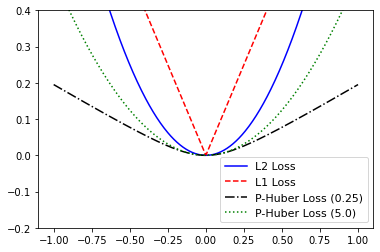

In [29]:
# Plot regression loss functions
x_vals = tf.linspace(-1., 1., 500)
target = tf.constant(0.)
funcs = [(l2, "b-", "L2 Loss"),
         (l1, "r--", "L1 Loss"),
         (phuber1, "k-.", "P-Huber Loss (0.25)"),
         (phuber2, "g:", "P-Huber Loss (5.0)")]
for func, line_type, func_name in funcs:
    plt.plot(x_vals, func(y_true=target, y_pred=x_vals), line_type, label=func_name)
plt.ylim(-0.2, 0.4)
plt.legend(loc="lower right", prop={"size": 11})
plt.show()

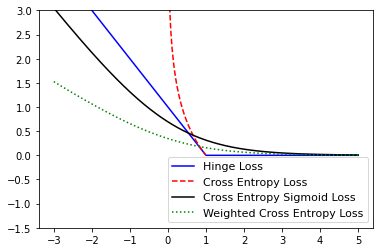

In [34]:
# Plot Classification loss functions
x_vals = tf.linspace(-3., 5., 500)
target = tf.fill([500, ], 1.)
funcs = [(hinge, "b-", "Hinge Loss"),
         (xentropy, "r--", "Cross Entropy Loss"), 
         (xentropy_sigmoid, "k-", "Cross Entropy Sigmoid Loss"),
         (xentropy_weighted, "g:", "Weighted Cross Entropy Loss")]
for func, line_type, label in funcs:
    plt.plot(x_vals, func(y_true=target, y_pred=x_vals), line_type, label=label)
plt.ylim(-1.5, 3)
plt.legend(loc="lower right", prop={"size": 11})
plt.show()

The cross-entropy sigmoid loss function is for use on unscaled logits and is preferred over computing the sigmoid lss and then the cross-entropy loss. Same for softmax cross-entropy and sparse softmax cross-entropy

## Alternate model metrics

* __R-Squared__ - Proportion of variance in the dependent variable that is explained by the independent variable (how much of the dependent variable can be explained by the independent variable). For larger number of features, use the adjusted R-squared
* __Root mean squared error__ - For continuous models, measures the difference between prediction and actual outputs via square root of the average squared error 
* __Confusion matrix__ - Matrix of predicted categories vs. actual categories
	- __Recall__ - fraction of true positives over all predicted positives
	- __Precision__ - fraction of true positives over all actual positives
	- __F-score__ - harmonic mean of precision and recall

Each metric will behave differently for different problems, some loss minimization strategies will be better than others

# Implementing Backpropagation

How to change variables in the model in a way that loss function is minimized - backpropagate errors through the network in order to update the variables in a way that minimizes the loss function. TensorFlow will modify variables in the network accordingly.

Specifying a good learning rate helps the convergence of algorithms, we must also specify a type of optimization to minimize the loss function


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Regression Algorithm

* Sample from normal distribution $N(1, 0.1)$
* Multiply them by a weight tensor and add a bias tensor
* Loss function: `L2 Norm`

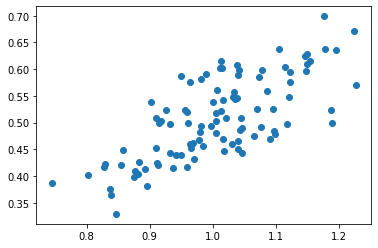

In [4]:
# Generating the data
np.random.seed(0)
x_vals = np.random.normal(1, 0.1, 100).astype(np.float32)
y_vals = (x_vals * (np.random.normal(1, 0.05, 100) - 0.5)).astype(np.float32)
plt.scatter(x_vals, y_vals)

In [3]:
# Defining the model
def my_output(X, weights, biases):
    return tf.add(tf.multiply(X, weights), biases)

def loss_func(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_pred - y_true))

my_opt = tf.optimizers.SGD(learning_rate=0.02)

Step #25 Weights: [-0.58009654] Biases: [0.91217995]
Loss = 0.13842473924160004
Step #50 Weights: [-0.5050226] Biases: [0.9813488]
Loss = 0.006441597361117601
Step #75 Weights: [-0.4791306] Biases: [0.9942327]
Loss = 0.01728087291121483
Step #100 Weights: [-0.4777394] Biases: [0.9807473]
Loss = 0.05371852591633797


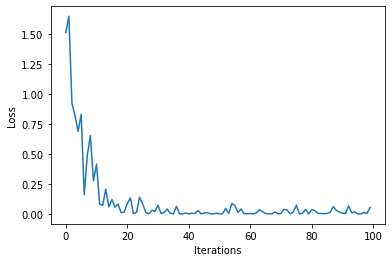

In [8]:
# Initialize variables
tf.random.set_seed(1)
np.random.seed(0)
weights = tf.Variable(tf.random.normal(shape=[1]))
biases = tf.Variable(tf.random.normal(shape=[1]))
history = list()

# Loop through training algorithm
for i in range(100):
    rand_index = np.random.choice(100)
    rand_x = [x_vals[rand_index]]
    rand_y = [y_vals[rand_index]]
    with tf.GradientTape() as tape:
        predictions = my_output(rand_x, weights, biases)
        loss = loss_func(rand_y, predictions)

    history.append(loss.numpy())
    gradients = tape.gradient(loss, [weights, biases])
    my_opt.apply_gradients(zip(gradients, [weights, biases]))
    if (i + 1) % 25 == 0:
        print(f"Step #{i+1} Weights: {weights.numpy()} Biases: {biases.numpy()}")
        print(f"Loss = {loss.numpy()}")

# Plotting the loss function
plt.plot(history)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.show()	
     

### Classification Algorithm

* Binary classification
* Generate 100 numbers from 2 normal distributions $N(-3, 1)$ and $N(3, 1)$
* Former in class 0 and latter in class 1
* Linear model optimized using sigmoid cross-entropy loss function

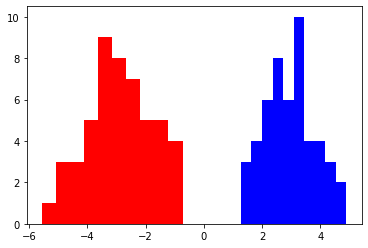

In [13]:
# Generating data
np.random.seed(0)
x_vals = np.concatenate((np.random.normal(-3, 1, 50), 
                         np.random.normal(3, 1, 50))).astype(np.float32) 
y_vals = np.concatenate((np.repeat(0., 50), np.repeat(1., 50))).astype(np.float32) 

plt.hist(x_vals[y_vals==1], color='b')
plt.hist(x_vals[y_vals==0], color='r')
plt.show()

Step #25 Weights: [-0.01804185] Biases: [0.44081175]
Loss = 0.5967269539833069
Step #50 Weights: [0.49321094] Biases: [0.37732077]
Loss = 0.3199256658554077
Step #75 Weights: [0.7071932] Biases: [0.32154965]
Loss = 0.03642747551202774
Step #100 Weights: [0.8395616] Biases: [0.30409005]
Loss = 0.028119441121816635


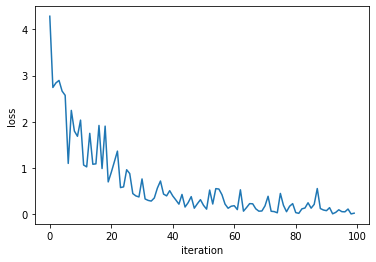

In [15]:
# Defining the model
def loss_func(y_true, y_pred):
    return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=y_pred))

# Initialize variables
tf.random.set_seed(1)
np.random.seed(0)
weights = tf.Variable(tf.random.normal(shape=[1]))
biases = tf.Variable(tf.random.normal(shape=[1]))
history = list()

# Train the model
for i in range(100):
    rand_index = np.random.choice(100)
    rand_x = [x_vals[rand_index]]
    rand_y = [y_vals[rand_index]]

    with tf.GradientTape() as tape:
        predictions = my_output(rand_x, weights, biases)
        loss = loss_func(rand_y, predictions)
    
    history.append(loss.numpy())
    gradients = tape.gradient(loss, [weights, biases])
    my_opt.apply_gradients(zip(gradients, [weights, biases]))
    
    if (i + 1) % 25 ==0:
        print(f"Step #{i+1} Weights: {weights.numpy()} Biases: {biases.numpy()}")
        print(f"Loss = {loss.numpy()}")

# Plot of loss
plt.plot(history)
plt.xlabel('iteration')
plt.ylabel("loss")
plt.show()

## Learning Rate

Optimization algorithms are sensitive to the choice of learning rate $\gamma$

* _Smaller learning rate_ - Converges slower, but more accurate result; good when nearing a minimum
* _Larger learning rate_ - Less accurate, but converges faster; prevents solution from stagnating, helps you get out of local minimum

Gradient descent can get stuck in local minima or saddle points. Consider implementing these techniques to include some variability in the model
* __Momemtum term__ - which adds on a fraction of the prior step's gradient descent value 
* __Vary optimizer step for different variables__ - larger steps for slower changing variables, smaller steps for faster changing variables, `ADAGRAD algorithm` or `ADADELTA algorithm`

# Batch and Stochastic Training

Have to choose the right batch size to ensure good convergence of the algorithm. Too small makes models too erratic, too large can be computationally expensive

* Put larger portion of training examples in and average the loss for gradient calculation
* Size of the training batch can be tuned
* Can still be stochastic by randomly choosing data points to be included

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [10]:
# By Batches
BATCH_SIZE = 20
np.random.seed(0)
x_vals = np.random.normal(1, 0.1, 100).astype(np.float32)
y_vals = (x_vals * (np.random.normal(1, 0.05, 100) - 0.5)).astype(np.float32)

def loss_func(y_true, y_pred):
	return tf.reduce_mean(tf.square(y_pred - y_true))

tf.random.set_seed(1)
np.random.seed(0)
weights = tf.Variable(tf.random.normal(shape=[1]))
biases = tf.Variable(tf.random.normal(shape=[1]))
history_batch = list()

for i in range(50):
	rand_index = np.random.choice(100, size=BATCH_SIZE)
	rand_x = [x_vals[rand_index]]
	rand_y = [y_vals[rand_index]]
	with tf.GradientTape() as tape:
		predictions = my_output(rand_x, weights, biases)
		loss = loss_func(rand_y, predictions)
	history_batch.append(loss.numpy())
	gradients = tape.gradient(loss, [weights, biases])
	my_opt.apply_gradients(zip(gradients, [weights, biases]))
	
	if (i + 1) % 25 == 0:
		print(f'Step # {i+1} Weights: {weights.numpy()} Biases: {biases.numpy()}')
		print(f'Loss = {loss.numpy()}') 

Step # 25 Weights: [-0.5558849] Biases: [0.93091005]
Loss = 0.058969467878341675
Step # 50 Weights: [-0.4879131] Biases: [0.98653436]
Loss = 0.01628759130835533


In [7]:
# By single data point stochastic sampling
tf.random.set_seed(1)
np.random.seed(0)

weights = tf.Variable(tf.random.normal(shape=[1]))
biases = tf.Variable(tf.random.normal(shape=[1]))
history_stochastic = list()

for i in range(50):
	rand_index = np.random.choice(100, size=1)
	rand_x = [x_vals[rand_index]]
	rand_y = [y_vals[rand_index]]
	with tf.GradientTape() as tape:
		predictions = my_output(rand_x, weights, biases)
		loss = loss_func(rand_y, predictions)
	history_stochastic.append(loss.numpy())
	gradients = tape.gradient(loss, [weights, biases])
	my_opt.apply_gradients(zip(gradients, [weights, biases]))
	if (i + 1) % 25 == 0:
		print(f'Step # {i+1} Weights: {weights.numpy()} Biases: {biases.numpy()}')
		print(f'Loss = {loss.numpy()}')

Step # 25 Weights: [-0.58009654] Biases: [0.91217995]
Loss = 0.13842473924160004
Step # 50 Weights: [-0.5050226] Biases: [0.9813488]
Loss = 0.006441597361117601


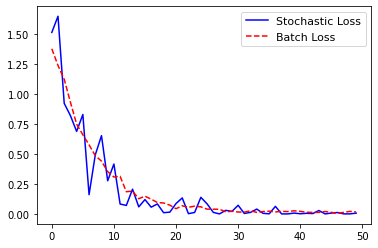

In [13]:
plt.plot(history_stochastic, "b-", label="Stochastic Loss")
plt.plot(history_batch, "r--", label="Batch Loss")
plt.legend(loc="upper right", prop={"size": 11})
plt.show()

Batch loss is much smoother compared to stochastic loss which is much more erratic. But stochastic loss achieved a lower loss amount compared to batching

* _Stochastic_ - randomness helps move out of local minimums; generally needs more iterations to converge
* _Batch_ - finds minimums quicker, but takes more computational resources

# Combining Everything Together

Create a binary classifier with Iris Dataset

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

In [3]:
BATCH_SIZE = 20

# Data Transformation
# Iris Setosa - 1 | Others - 0
iris = tfds.load("iris", split="train[:90%]", as_supervised=True)
iris_test = tfds.load("iris", split="train[90%:]", as_supervised=True)

def iris2d(features, label):
    return features[2:], tf.cast((label == 0), dtype=tf.float32)

train_generator = (iris
                   .map(iris2d)
                   .shuffle(buffer_size=100)
                   .batch(BATCH_SIZE)
                    )
test_generator = iris_test.map(iris2d).batch(1)

In [4]:
# Declare Model, Loss function, and Optimizer
def linear_model(X, A, b):
    my_output = tf.add(tf.matmul(X, A), b)
    return tf.squeeze(my_output)

def xentropy(y_true, y_pred):
    return tf.reduce_mean(
        tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=y_pred)
    )

my_opt = tf.optimizers.SGD(learning_rate=0.02)

In [5]:
tf.random.set_seed(30)
np.random.seed(0)
A = tf.Variable(tf.random.normal(shape=[2,1]))
b = tf.Variable(tf.random.normal(shape=[1]))
history = []

for i in range(300):
    iteration_loss = []
    for features, label in train_generator:
        with tf.GradientTape() as tape:
            predictions = linear_model(features, A, b)
            loss = xentropy(label, predictions)
        iteration_loss.append(loss.numpy())
        gradients = tape.gradient(loss, [A, b])
        my_opt.apply_gradients(zip(gradients, [A, b]))
    history.append(np.mean(iteration_loss))
    if (i + 1) % 30 == 0:
        print(f"Step #{i+1} Weights: {A.numpy().T} Biases: {b.numpy()}")
        print(f"Loss = {loss.numpy()}")
   

Step #30 Weights: [[-0.54530674  0.38814473]] Biases: [-0.04928875]
Loss = 0.3954269289970398
Step #60 Weights: [[-0.61728215  0.141161  ]] Biases: [0.55316615]
Loss = 0.40838298201560974
Step #90 Weights: [[-0.6928326  -0.06775098]] Biases: [1.0552747]
Loss = 0.25996488332748413
Step #120 Weights: [[-0.75983655 -0.24279076]] Biases: [1.4784505]
Loss = 0.25564444065093994
Step #150 Weights: [[-0.8204323  -0.39191252]] Biases: [1.8420074]
Loss = 0.1817469596862793
Step #180 Weights: [[-0.87845975 -0.5213905 ]] Biases: [2.1548467]
Loss = 0.23902565240859985
Step #210 Weights: [[-0.9316568  -0.63453674]] Biases: [2.428805]
Loss = 0.13237255811691284
Step #240 Weights: [[-0.9771712 -0.7342531]] Biases: [2.6734464]
Loss = 0.14968031644821167
Step #270 Weights: [[-1.0248817 -0.8250804]] Biases: [2.8907466]
Loss = 0.06719071418046951
Step #300 Weights: [[-1.0651517  -0.90627784]] Biases: [3.0890079]
Loss = 0.07971730083227158


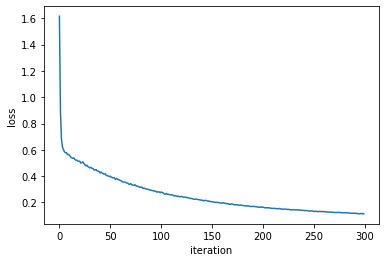

In [6]:
plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.show()

test cross-entropy is 0.10748794674873352


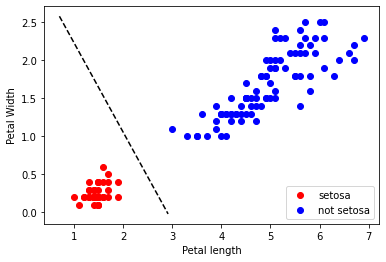

In [10]:
# Checking performance on test dataset
predictions = []
labels = []
for features, label in test_generator:
    predictions.append(linear_model(features, A, b).numpy())
    labels.append(label.numpy()[0])

test_loss = xentropy(np.array(labels), np.array(predictions)).numpy()
print(f"test cross-entropy is {test_loss}")

coefficients = np.ravel(A.numpy())
intercept = b.numpy()
for j, (features, label) in enumerate(train_generator):
    setosa_mask = label.numpy() == 1
    setosa = features.numpy()[setosa_mask]
    non_setosa = features.numpy()[~setosa_mask]
    plt.scatter(setosa[:, 0], setosa[:, 1], c="red", label="setosa")
    plt.scatter(non_setosa[:, 0], non_setosa[:, 1], c="blue", label="not setosa")
    if j == 0:
        plt.legend(loc="lower right")
# Computing and plotting the decision function
a = -coefficients[0] / coefficients[1]
xx = np.linspace(plt.xlim()[0], plt.xlim()[1], num=10000)
yy = a * xx - intercept / coefficients[1]
on_the_plot = (yy > plt.ylim()[0]) & (yy < plt.ylim()[1])
plt.plot(xx[on_the_plot], yy[on_the_plot], 'k--')
plt.xlabel('Petal length')
plt.ylabel('Petal Width')
plt.show()

The separating line is defined by multiple parameters. It depends on the data, the network architecture, and the learning process, even the starting weights (randomly generated here) will return a slightly different outcome.

This solution shows a solid distinction between the 2 classes of flowers, based on the features used to create the model. However, it might not be the best. For instances, after adding new observations, the model might not be able to distinguish as well. Models need to be __better generalized__ to account for new additions in data